In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

models = [
    "Árbol de decisión (depth=4)",
    "KNN (k=11)",
    "Naive Bayes (Bernoulli)",
    "Random Forest",
    "Regresión logística",
    "SVM",
    "XGBoost",
]

metrics_mean = pd.DataFrame({
    "Modelo": models,
    "Accuracy": [0.8966, 0.8898, 0.8557,  0.9182, 0.9000, 0.8455, 0.8989],
    "Precision": [0.8215, 0.8130, 0.6288, 0.8478, 0.8368, 0.6024, 0.7781],
    "Recall": [0.7173, 0.6700, 0.8880, 0.7775, 0.6948, 0.9314, 0.7676],
    "F1-score": [0.7536, 0.7300, 0.7347, 0.8083, 0.7553, 0.7287, 0.7699],
    "AUC": [0.9324, 0.9468, 0.9537, 0.9630, 0.9571, 0.9514, 0.9646],
})

metrics_std = pd.DataFrame({
    "Modelo": models,
    "Accuracy": [0.0285, 0.0301, 0.0380, 0.0304, 0.0232, 0.0306, 0.0212],
    "Precision": [0.1060, 0.0692, 0.0681, 0.0819, 0.0623, 0.0704, 0.0551],
    "Recall": [0.1141, 0.1145, 0.0411, 0.0841, 0.0862, 0.0523, 0.0870],
    "F1-score": [0.0630, 0.0854, 0.0555, 0.0674, 0.0597, 0.0562, 0.0547],
    "AUC": [0.0181, 0.0228, 0.0132, 0.0150, 0.0101, 0.0161, 0.0144],
})

summary_df = pd.DataFrame({
    "Modelo": models,
    "Accuracy": ["0.8409 ± 0.0285", "0.8898 ± 0.0301", "0.7739 ± 0.0365", "0.8830 ± 0.0297", "0.9000 ± 0.0232", "0.8455 ± 0.0306", "0.8989 ± 0.0212"],
    "Precision": ["0.5989 ± 0.1060", "0.8130 ± 0.0692", "0.0000 ± 0.0000", "0.6995 ± 0.0801", "0.8368 ± 0.0623", "0.6024 ± 0.0704", "0.7781 ± 0.0551"],
    "Recall": ["0.9258 ± 0.1141", "0.6700 ± 0.1145", "0.0000 ± 0.0000", "0.8602 ± 0.0509", "0.6948 ± 0.0862", "0.9314 ± 0.0523", "0.7676 ± 0.0870"],
    "F1-score": ["0.7238 ± 0.0630", "0.7300 ± 0.0854", "0.0000 ± 0.0000", "0.7675 ± 0.0451", "0.7553 ± 0.0597", "0.7287 ± 0.0562", "0.7699 ± 0.0547"],
    "AUC": ["0.9389 ± 0.0181", "0.9468 ± 0.0228", "0.5000 ± 0.0000", "0.9585 ± 0.0164", "0.9571 ± 0.0101", "0.9514 ± 0.0161", "0.9646 ± 0.0144"],
})

summary_df

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Árbol de decisión (depth=4),0.8409 ± 0.0285,0.5989 ± 0.1060,0.9258 ± 0.1141,0.7238 ± 0.0630,0.9389 ± 0.0181
1,KNN (k=11),0.8898 ± 0.0301,0.8130 ± 0.0692,0.6700 ± 0.1145,0.7300 ± 0.0854,0.9468 ± 0.0228
2,Naive Bayes (Bernoulli),0.7739 ± 0.0365,0.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,0.5000 ± 0.0000
3,Random Forest,0.8830 ± 0.0297,0.6995 ± 0.0801,0.8602 ± 0.0509,0.7675 ± 0.0451,0.9585 ± 0.0164
4,Regresión logística,0.9000 ± 0.0232,0.8368 ± 0.0623,0.6948 ± 0.0862,0.7553 ± 0.0597,0.9571 ± 0.0101
5,SVM,0.8455 ± 0.0306,0.6024 ± 0.0704,0.9314 ± 0.0523,0.7287 ± 0.0562,0.9514 ± 0.0161
6,XGBoost,0.8989 ± 0.0212,0.7781 ± 0.0551,0.7676 ± 0.0870,0.7699 ± 0.0547,0.9646 ± 0.0144


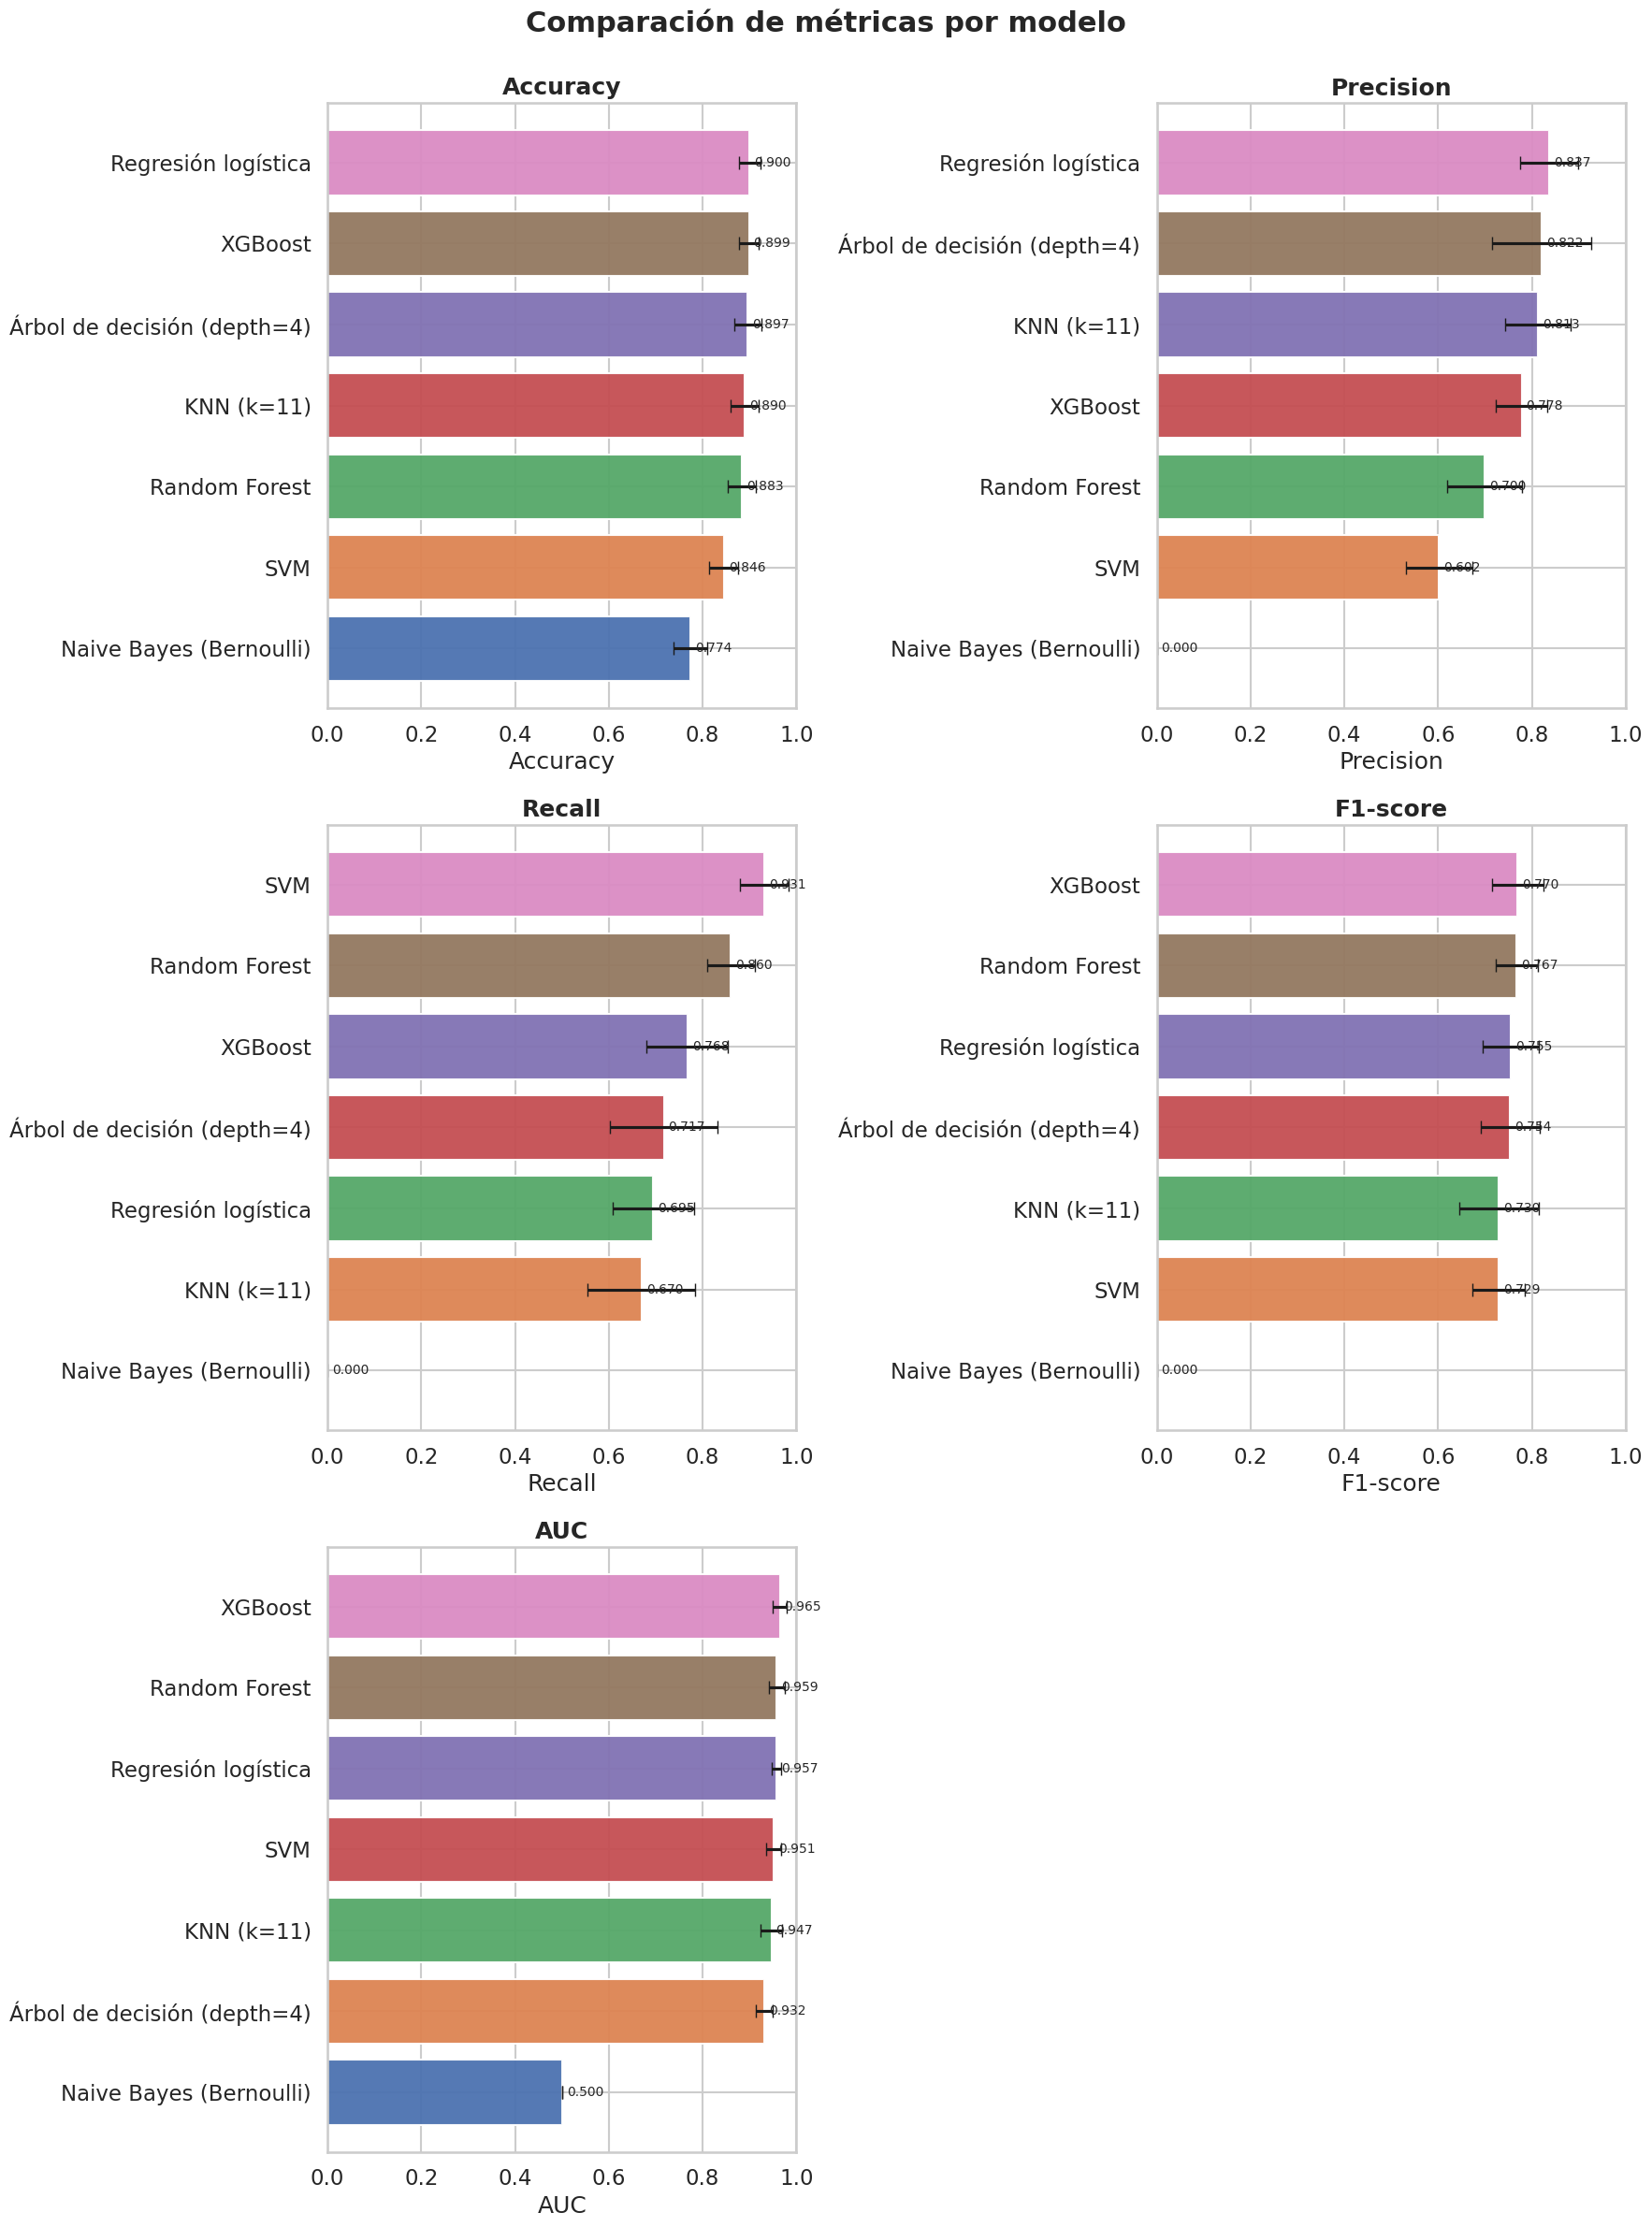

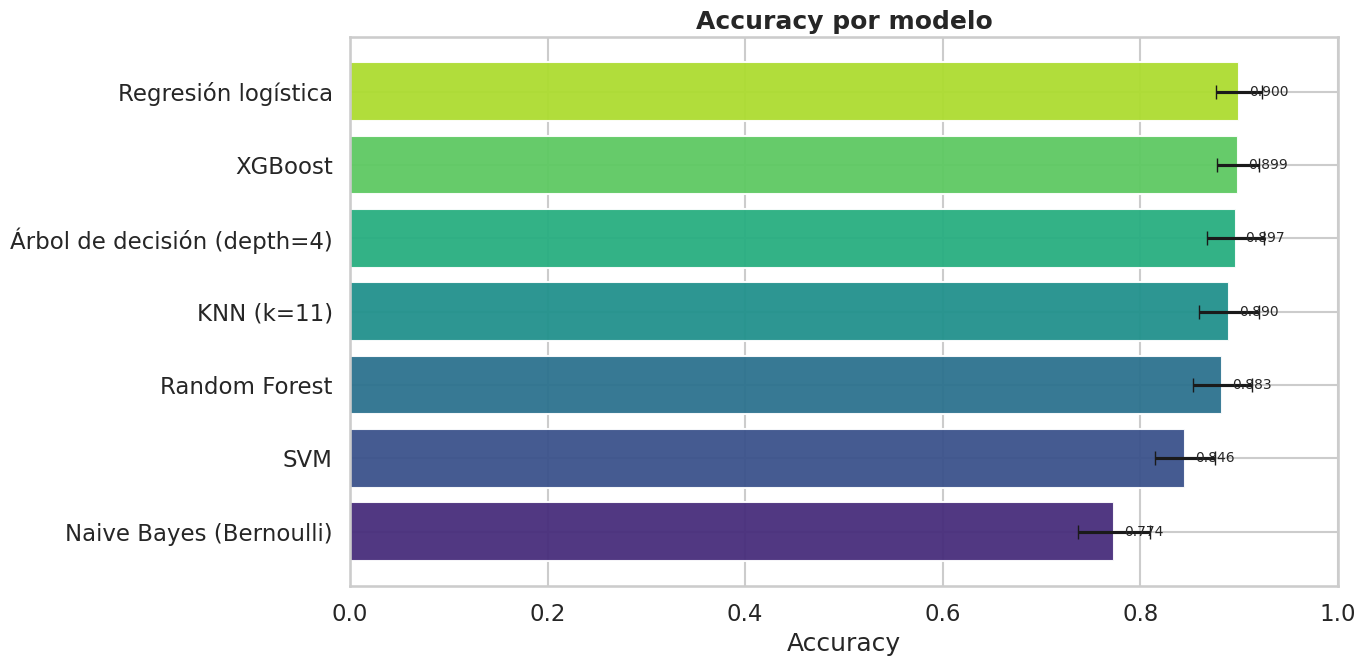

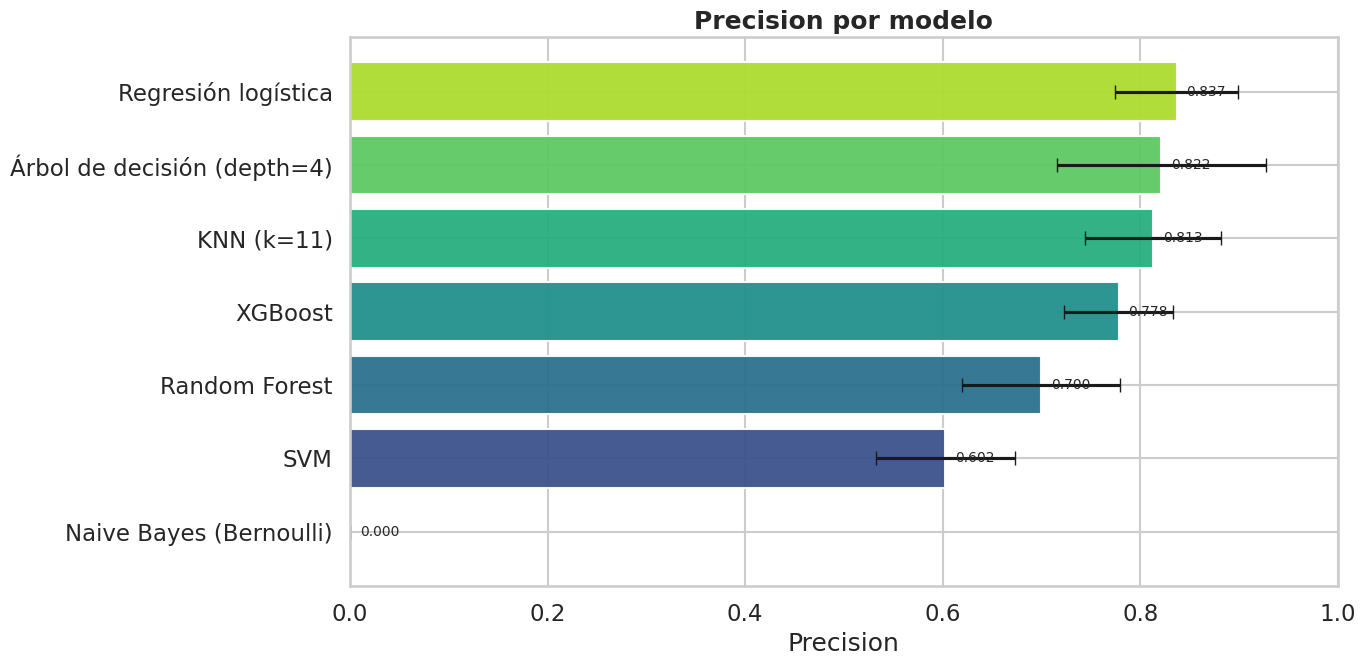

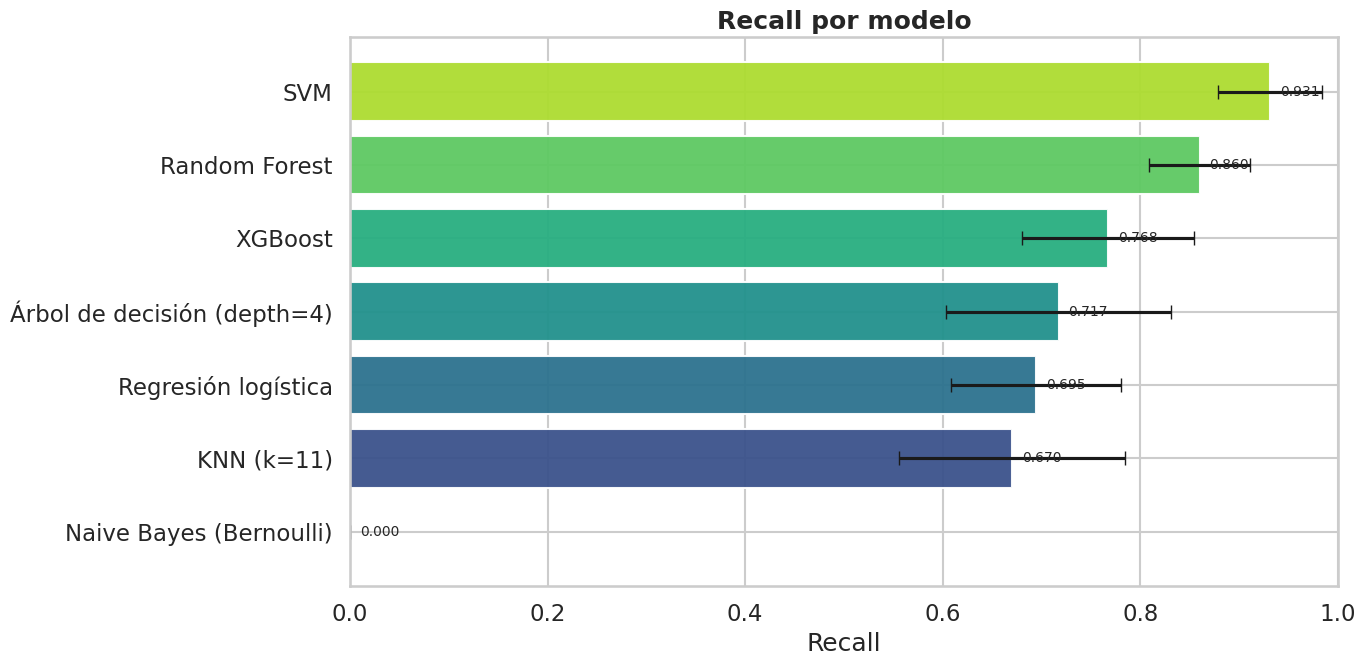

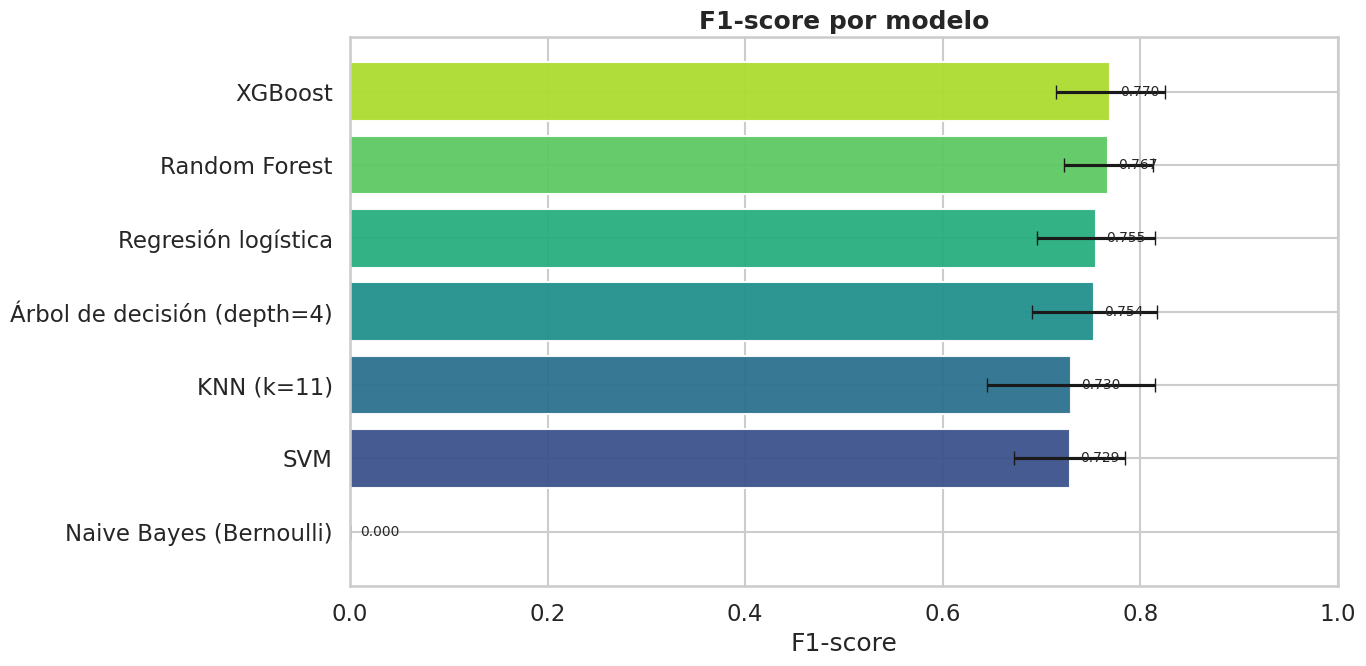

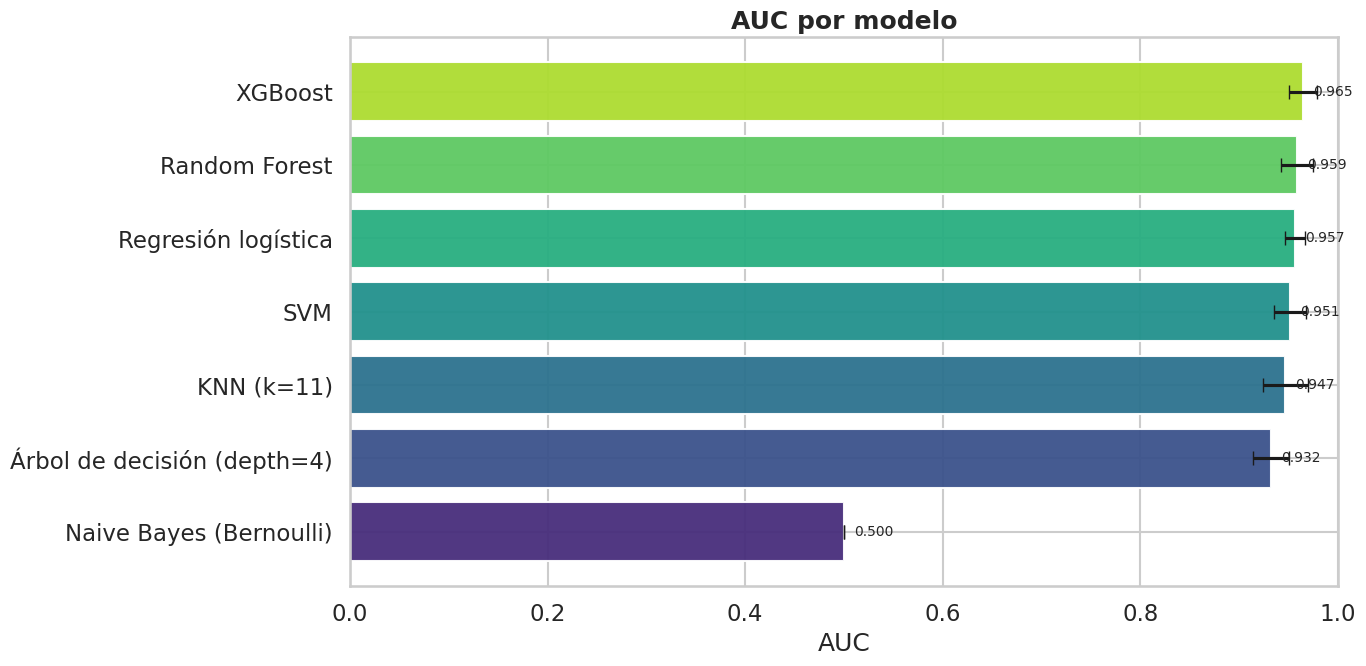

In [8]:
metric_order = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
palette = sns.color_palette("deep", n_colors=len(models))

fig, axes = plt.subplots(3, 2, figsize=(18, 24))
axes = axes.flatten()

for idx, metric in enumerate(metric_order):
    ax = axes[idx]
    plot_df = metrics_mean.sort_values(metric, ascending=True)
    plot_std = metrics_std.set_index("Modelo").loc[plot_df["Modelo"]][metric].values
    bars = ax.barh(plot_df["Modelo"], plot_df[metric], xerr=plot_std, color=palette, capsize=5, alpha=0.95)
    ax.set_title(metric, weight="bold")
    ax.set_xlim(0, 1.0)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    for bar in bars:
        value = bar.get_width()
        ax.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=10)

axes[-1].axis("off")
fig.suptitle("Comparación de métricas por modelo", fontsize=22, weight="bold", y=0.995)
plt.tight_layout()
plt.show()

for metric in metric_order:
    plot_df = metrics_mean.sort_values(metric, ascending=True)
    plot_std = metrics_std.set_index("Modelo").loc[plot_df["Modelo"]][metric].values
    plt.figure(figsize=(14, 7))
    bars = plt.barh(plot_df["Modelo"], plot_df[metric], xerr=plot_std, color=sns.color_palette("viridis", n_colors=len(models)), capsize=5, alpha=0.95)
    plt.title(f"{metric} por modelo", weight="bold")
    plt.xlim(0, 1.0)
    plt.xlabel(metric)
    plt.ylabel("")
    for bar in bars:
        value = bar.get_width()
        plt.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=10)
    plt.tight_layout()
    plt.show()